In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Load Give Me Some Credit
gmsc = pd.read_csv(
    r'C:\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\data\raw\GiveMeSomeCredit\cs-training.csv',
    index_col=0
)   # used absolute path
print(gmsc.shape)           
print(gmsc.dtypes)          # Check all column types
print(gmsc.isnull().sum())  # Check missing values
gmsc.head()                 # preview top 5 rows

(150000, 11)
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNot

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# Delinquency rate
print(f"Delinquency rate: {gmsc['SeriousDlqin2yrs'].mean():.3f}")

# This number drives your synthetic delinquency_flag generation.
# When your generator runs np.random.random() < 0.067, it creates 6.7% delinquent customers.

Delinquency rate: 0.067


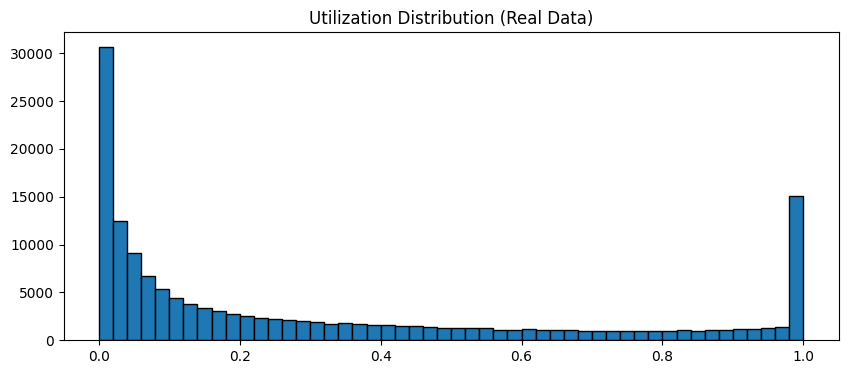

In [4]:
# Study utilization distribution
util = gmsc['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)  # Clip to [0,1] — a few records have utilization > 1 due to data errors

fig, ax = plt.subplots(figsize=(10, 4))         #Creating Plot area 
ax.hist(util, bins=50, edgecolor='black')       #plotting histogram
ax.set_title('Utilization Distribution (Real Data)')        
plt.savefig(r'C:\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\notebooks/utilization_dist.png', dpi=100, bbox_inches='tight')  #used absolute path
plt.show()

# Key insight: most customers < 0.4 utilization, spike near 1.0 for distressed accounts

In [ ]:
# Correlations with delinquency
corr_with_target = gmsc.corrwith(gmsc['SeriousDlqin2yrs']).sort_values()
print(corr_with_target)

# NOTE: RevolvingUtilization shows near-zero correlation here because
# the raw column has extreme outliers (values up to 50,000+) that distort Pearson correlation. Check the actual range:

print(f"\nUtilization max (raw): {gmsc['RevolvingUtilizationOfUnsecuredLines'].max():.1f}")
print(f"Utilization max (clipped to [0,1]): {gmsc['RevolvingUtilizationOfUnsecuredLines'].clip(0,1).max():.1f}")

# Corrected correlation after clipping:
corr_clipped = gmsc['RevolvingUtilizationOfUnsecuredLines'].clip(0,1).corr(gmsc['SeriousDlqin2yrs'])
print(f"Utilization correlation (clipped): {corr_clipped:.4f}")

# Now shows as a meaningful predictor   (came out to 0.2781)

age                                    -0.115386
NumberOfOpenCreditLinesAndLoans        -0.029669
MonthlyIncome                          -0.019746
DebtRatio                              -0.007602
NumberRealEstateLoansOrLines           -0.007038
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberOfDependents                      0.046048
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfTimes90DaysLate                 0.117175
NumberOfTime30-59DaysPastDueNotWorse    0.125587
SeriousDlqin2yrs                        1.000000
dtype: float64

Utilization max (raw): 50708.0
Utilization max (clipped to [0,1]): 1.0
Utilization correlation (clipped): 0.2781


In [6]:
print(gmsc['RevolvingUtilizationOfUnsecuredLines'].describe())
# You'll see max is something like 50,708 — data errors

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


In [ ]:
# ── Key EDA Findings ──

delinquency_rate = gmsc['SeriousDlqin2yrs'].mean()
util_corr_clipped = gmsc['RevolvingUtilizationOfUnsecuredLines'].clip(0,1).corr(gmsc['SeriousDlqin2yrs'])
late90_corr = gmsc['NumberOfTimes90DaysLate'].corr(gmsc['SeriousDlqin2yrs'])
late3059_corr = gmsc['NumberOfTime30-59DaysPastDueNotWorse'].corr(gmsc['SeriousDlqin2yrs'])

print("=" * 55)
print("  KEY EDA FINDINGS")
print("=" * 55)
print(f"  Delinquency rate:              {delinquency_rate:.3f}  (6.7%)")
print(f"  Utilization corr (clipped):    {util_corr_clipped:.4f}")
print(f"  90-days-late corr:             {late90_corr:.4f}")
print(f"  30-59-days-late corr:          {late3059_corr:.4f}")
print("=" * 55)
print()
print("DESIGN DECISIONS DRIVEN BY THESE NUMBERS:")
print(f"  → Synthetic delinquency_flag set to {delinquency_rate:.3f} probability")
print(f"  → Utilization clipped to [0,1] in all downstream use")
print(f"  → Rule score gives delinquency_flag 30pts (strongest signal)")
print(f"  → RF trained with class_weight='balanced' (93/7 imbalance)")
print(f"  → SHAP expected to rank late-payment features at top")

  KEY EDA FINDINGS
  Delinquency rate:              0.067  (6.7%)
  Utilization corr (clipped):    0.2781
  90-days-late corr:             0.1172
  30-59-days-late corr:          0.1256

DESIGN DECISIONS DRIVEN BY THESE NUMBERS:
  → Synthetic delinquency_flag set to 0.067 probability
  → Utilization clipped to [0,1] in all downstream use
  → Rule score gives delinquency_flag 30pts (strongest signal)
  → RF trained with class_weight='balanced' (93/7 imbalance)
  → SHAP expected to rank late-payment features at top


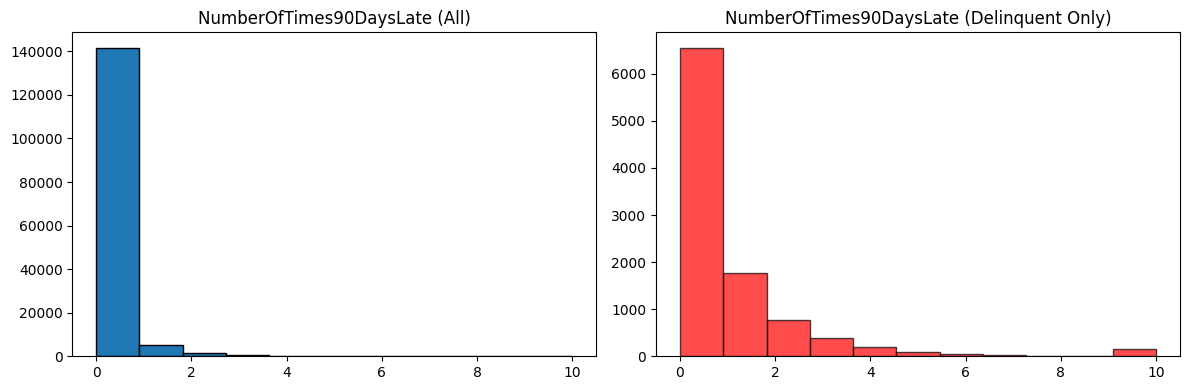

In [ ]:
# Late(90 days) visualisation for all vs delinquent only

late = gmsc["NumberOfTimes90DaysLate"].clip(0, 10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# All customers
axes[0].hist(late, bins=11, edgecolor="black")
axes[0].set_title("NumberOfTimes90DaysLate (All)")

# Only delinquent customers
late_delinq = late[gmsc["SeriousDlqin2yrs"]==1]
axes[1].hist(late_delinq, bins=11, edgecolor="black", color="red", alpha=0.7)
axes[1].set_title("NumberOfTimes90DaysLate (Delinquent Only)")

plt.tight_layout()
plt.savefig(r"\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\notebooks/late_payments_dist.png", dpi=100, bbox_inches="tight")
plt.show()

This compares the distribution of 90-day late payments between all customers and delinquent customers. The side-by-side layout uses plt.subplots(1, 2) — one row, two columns. axes[0] and axes[1] index into the array of subplot axes. What you will see: for all customers, the distribution is extremely right-skewed (most have 0 late payments). For delinquent customers, the distribution shifts right — many have 1–3 or more late payments. plt.tight_layout() prevents the subplot titles from overlapping with each other.

Median debt ratio: 0.367
75th percentile: 0.868
90th percentile: 5.000


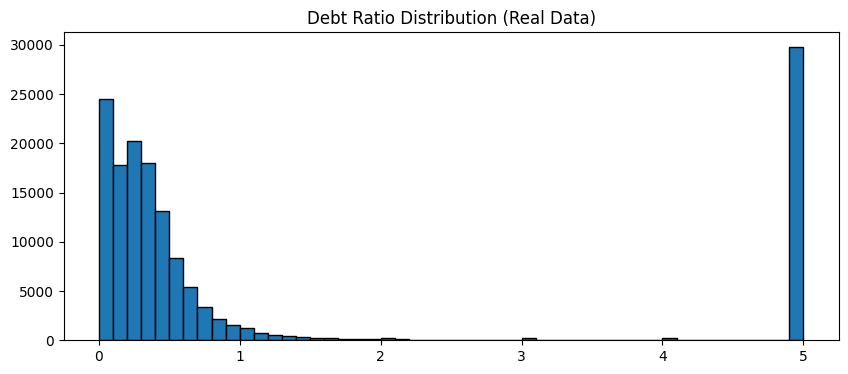

In [ ]:
# Debt Ratio for later

debt = gmsc["DebtRatio"].clip(0, 5)  # Clip extreme outliers 

print(f"Median debt ratio: {debt.median():.3f}")
print(f"75th percentile: {debt.quantile(0.75):.3f}")
print(f"90th percentile: {debt.quantile(0.90):.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(debt, bins=50, edgecolor="black")
ax.set_title("Debt Ratio Distribution (Real Data)")
plt.savefig(r"\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\notebooks/debt_ratio_dist.png", dpi=100, bbox_inches="tight")
plt.show()

.clip(0, 5) excludes extreme outliers for readability — some records have debt ratios of 9999 (data errors). 

.quantile() computes the value below which X% of observations fall. The 75th and 90th percentile numbers tell you the typical debt load for most borrowers — this informs how you set the debt_ratio in the risk agent's feature map later (Phase 4).

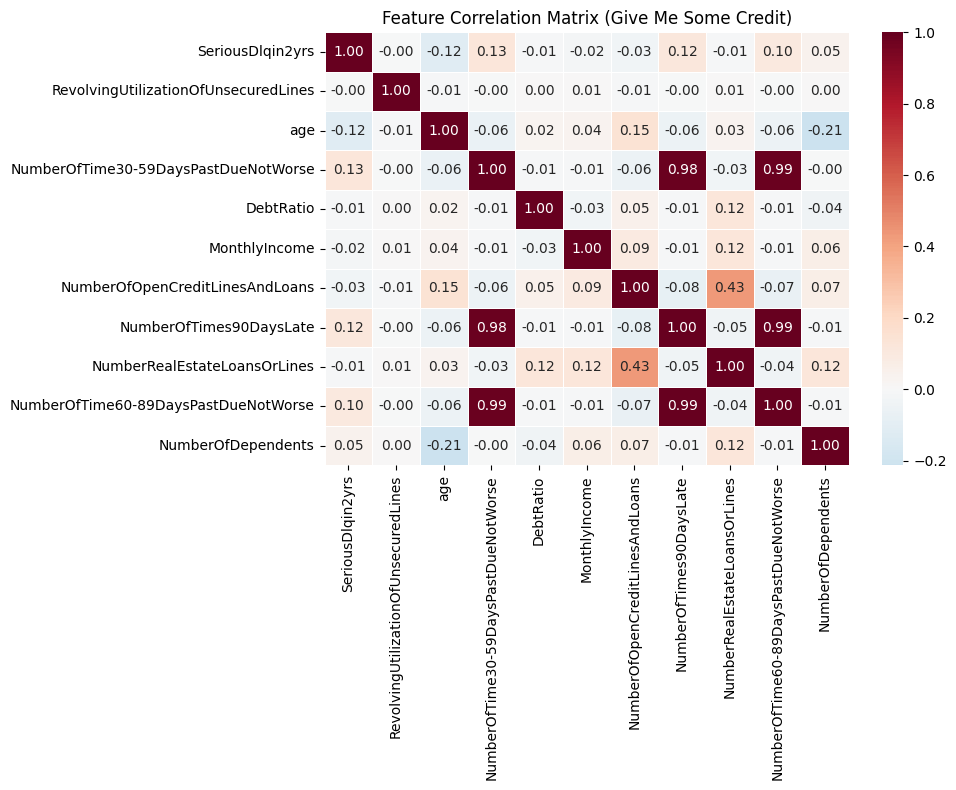

In [ ]:
#Feature Correlation Matrix for GMSC 

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = gmsc.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Feature Correlation Matrix (Give Me Some Credit)")

plt.tight_layout()
plt.savefig(r"\Users\yashc\OneDrive\Desktop\code\Risk-Copilot\notebooks/correlation_heatmap.png", dpi=100, bbox_inches="tight")
plt.show()